01. Linear Model

In [1]:
import pandas as pd
import numpy as np
path = "./diabetes.csv"
df = pd.read_csv(path)

df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Count missing values (zeros in columns),fill missing with Nan then repalce them with median  

In [2]:
cols_with_zero_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
(df[cols_with_zero_missing] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [4]:
import numpy as np
df_clean = df.copy()
df_clean[cols_with_zero_missing] = df_clean[cols_with_zero_missing].replace(0,np.nan)

df_clean.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [5]:
for col in cols_with_zero_missing:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
df_clean.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
print(f"Duplicate rows: {df_clean.duplicated().sum()}") # No duplicated rows 

Duplicate rows: 0


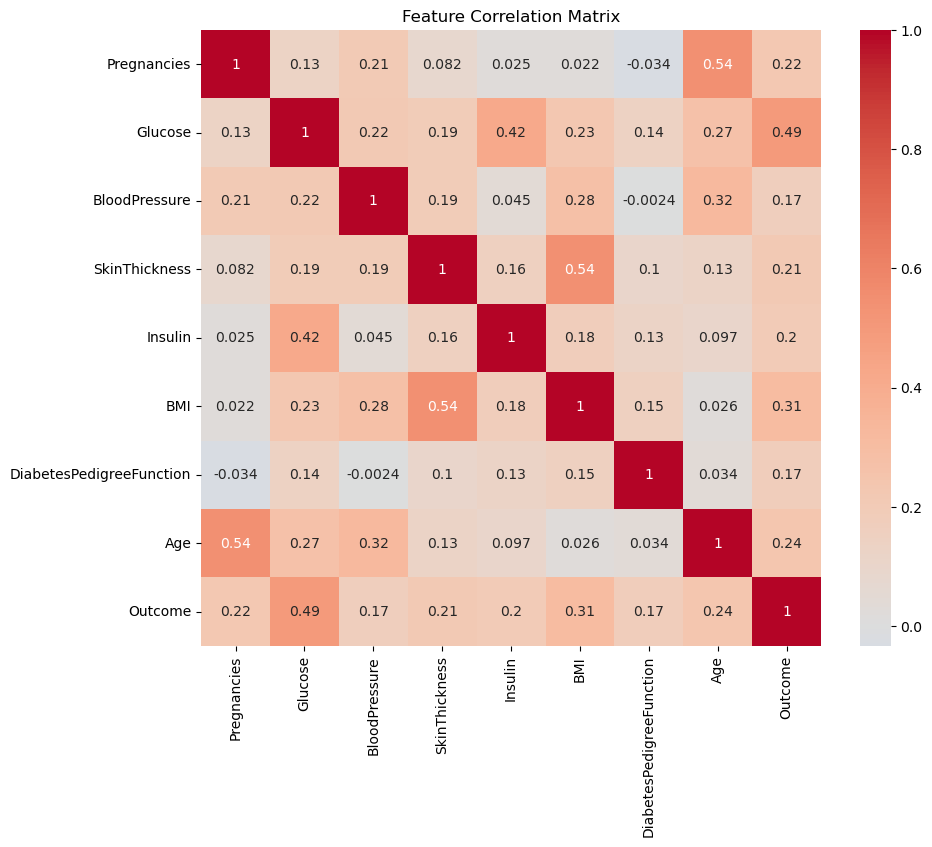

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
correlation_matrix = df_clean.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()


Select features to train model, Split training and testing set 80%,20% 

In [8]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

X = df_clean[features]  # Independent variables
y = df_clean['Outcome']  # Dependent variable (target)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (768, 8)
Target shape: (768,)


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 
#random_state=42 --> same test set each time 
# stratify=y --> same class destribution

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training set size: 614
Testing set size: 154
Training features shape: (614, 8)
Testing features shape: (154, 8)


Train the model and get coefficients then make predicition 

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Coefficients:")
for feature, coef in zip(features, model.coef_):
    print(f"{feature}: {coef:.4f}")

print(f"Intercept: {model.intercept_:.4f}")

Model Coefficients:
Pregnancies: 0.0187
Glucose: 0.0069
BloodPressure: -0.0003
SkinThickness: -0.0001
Insulin: -0.0001
BMI: 0.0156
DiabetesPedigreeFunction: 0.1136
Age: 0.0017
Intercept: -1.1321


Make predicition and test model 

In [15]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import mean_squared_error,accuracy_score
print("RMSE METRICS:")
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Testing RMSE:  {test_rmse:.4f}")

RMSE METRICS:
Training RMSE: 0.3877
Testing RMSE:  0.4144


In [19]:
accuracy = accuracy_score(y, (model.predict(X) >= 0.5).astype(int))
print(f"Overall Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Overall Model Accuracy: 0.7721 (77.21%)


02/

In [ ]:
import keras
import tensorflow as tf

